## 1. Load the data file and explore the data, showing size, data descriptions, data distributions with boxplot, pairplots 

In [1]:
import pandas as pd

df = pd.read_csv('written-test-2025-06-30-exam-1.csv')

In [29]:
df.dtypes

V0        str
V1    float64
V2    float64
V3    float64
V4    float64
V5    float64
V6    float64
V7    float64
V8    float64
dtype: object

In [30]:
df.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8
0,ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22
1,ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22
2,ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22
3,AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22
4,AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22


In [31]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} features")
print('----------------------------------------------------')
df.info()
print('----------------------------------------------------')
df.describe()

The dataset has 1484 rows and 9 features
----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V0      1484 non-null   str    
 1   V1      1484 non-null   float64
 2   V2      1484 non-null   float64
 3   V3      1484 non-null   float64
 4   V4      1484 non-null   float64
 5   V5      1484 non-null   float64
 6   V6      1484 non-null   float64
 7   V7      1484 non-null   float64
 8   V8      1484 non-null   float64
dtypes: float64(8), str(1)
memory usage: 104.5 KB
----------------------------------------------------


,V1,V2,V3,V4,V5,V6,V7,V8
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.500121,0.499933,0.500034,0.261186,0.504717,0.007500,0.499885,0.276199
std,0.137299,0.123924,0.086670,0.137098,0.048351,0.075683,0.057797,0.106491
min,0.110000,0.130000,0.210000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,0.410000,0.420000,0.460000,0.170000,0.500000,0.000000,0.480000,0.220000
50%,0.490000,0.490000,0.510000,0.220000,0.500000,0.000000,0.510000,0.220000
75%,0.580000,0.570000,0.550000,0.320000,0.500000,0.000000,0.530000,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.830000,0.730000,1.000000


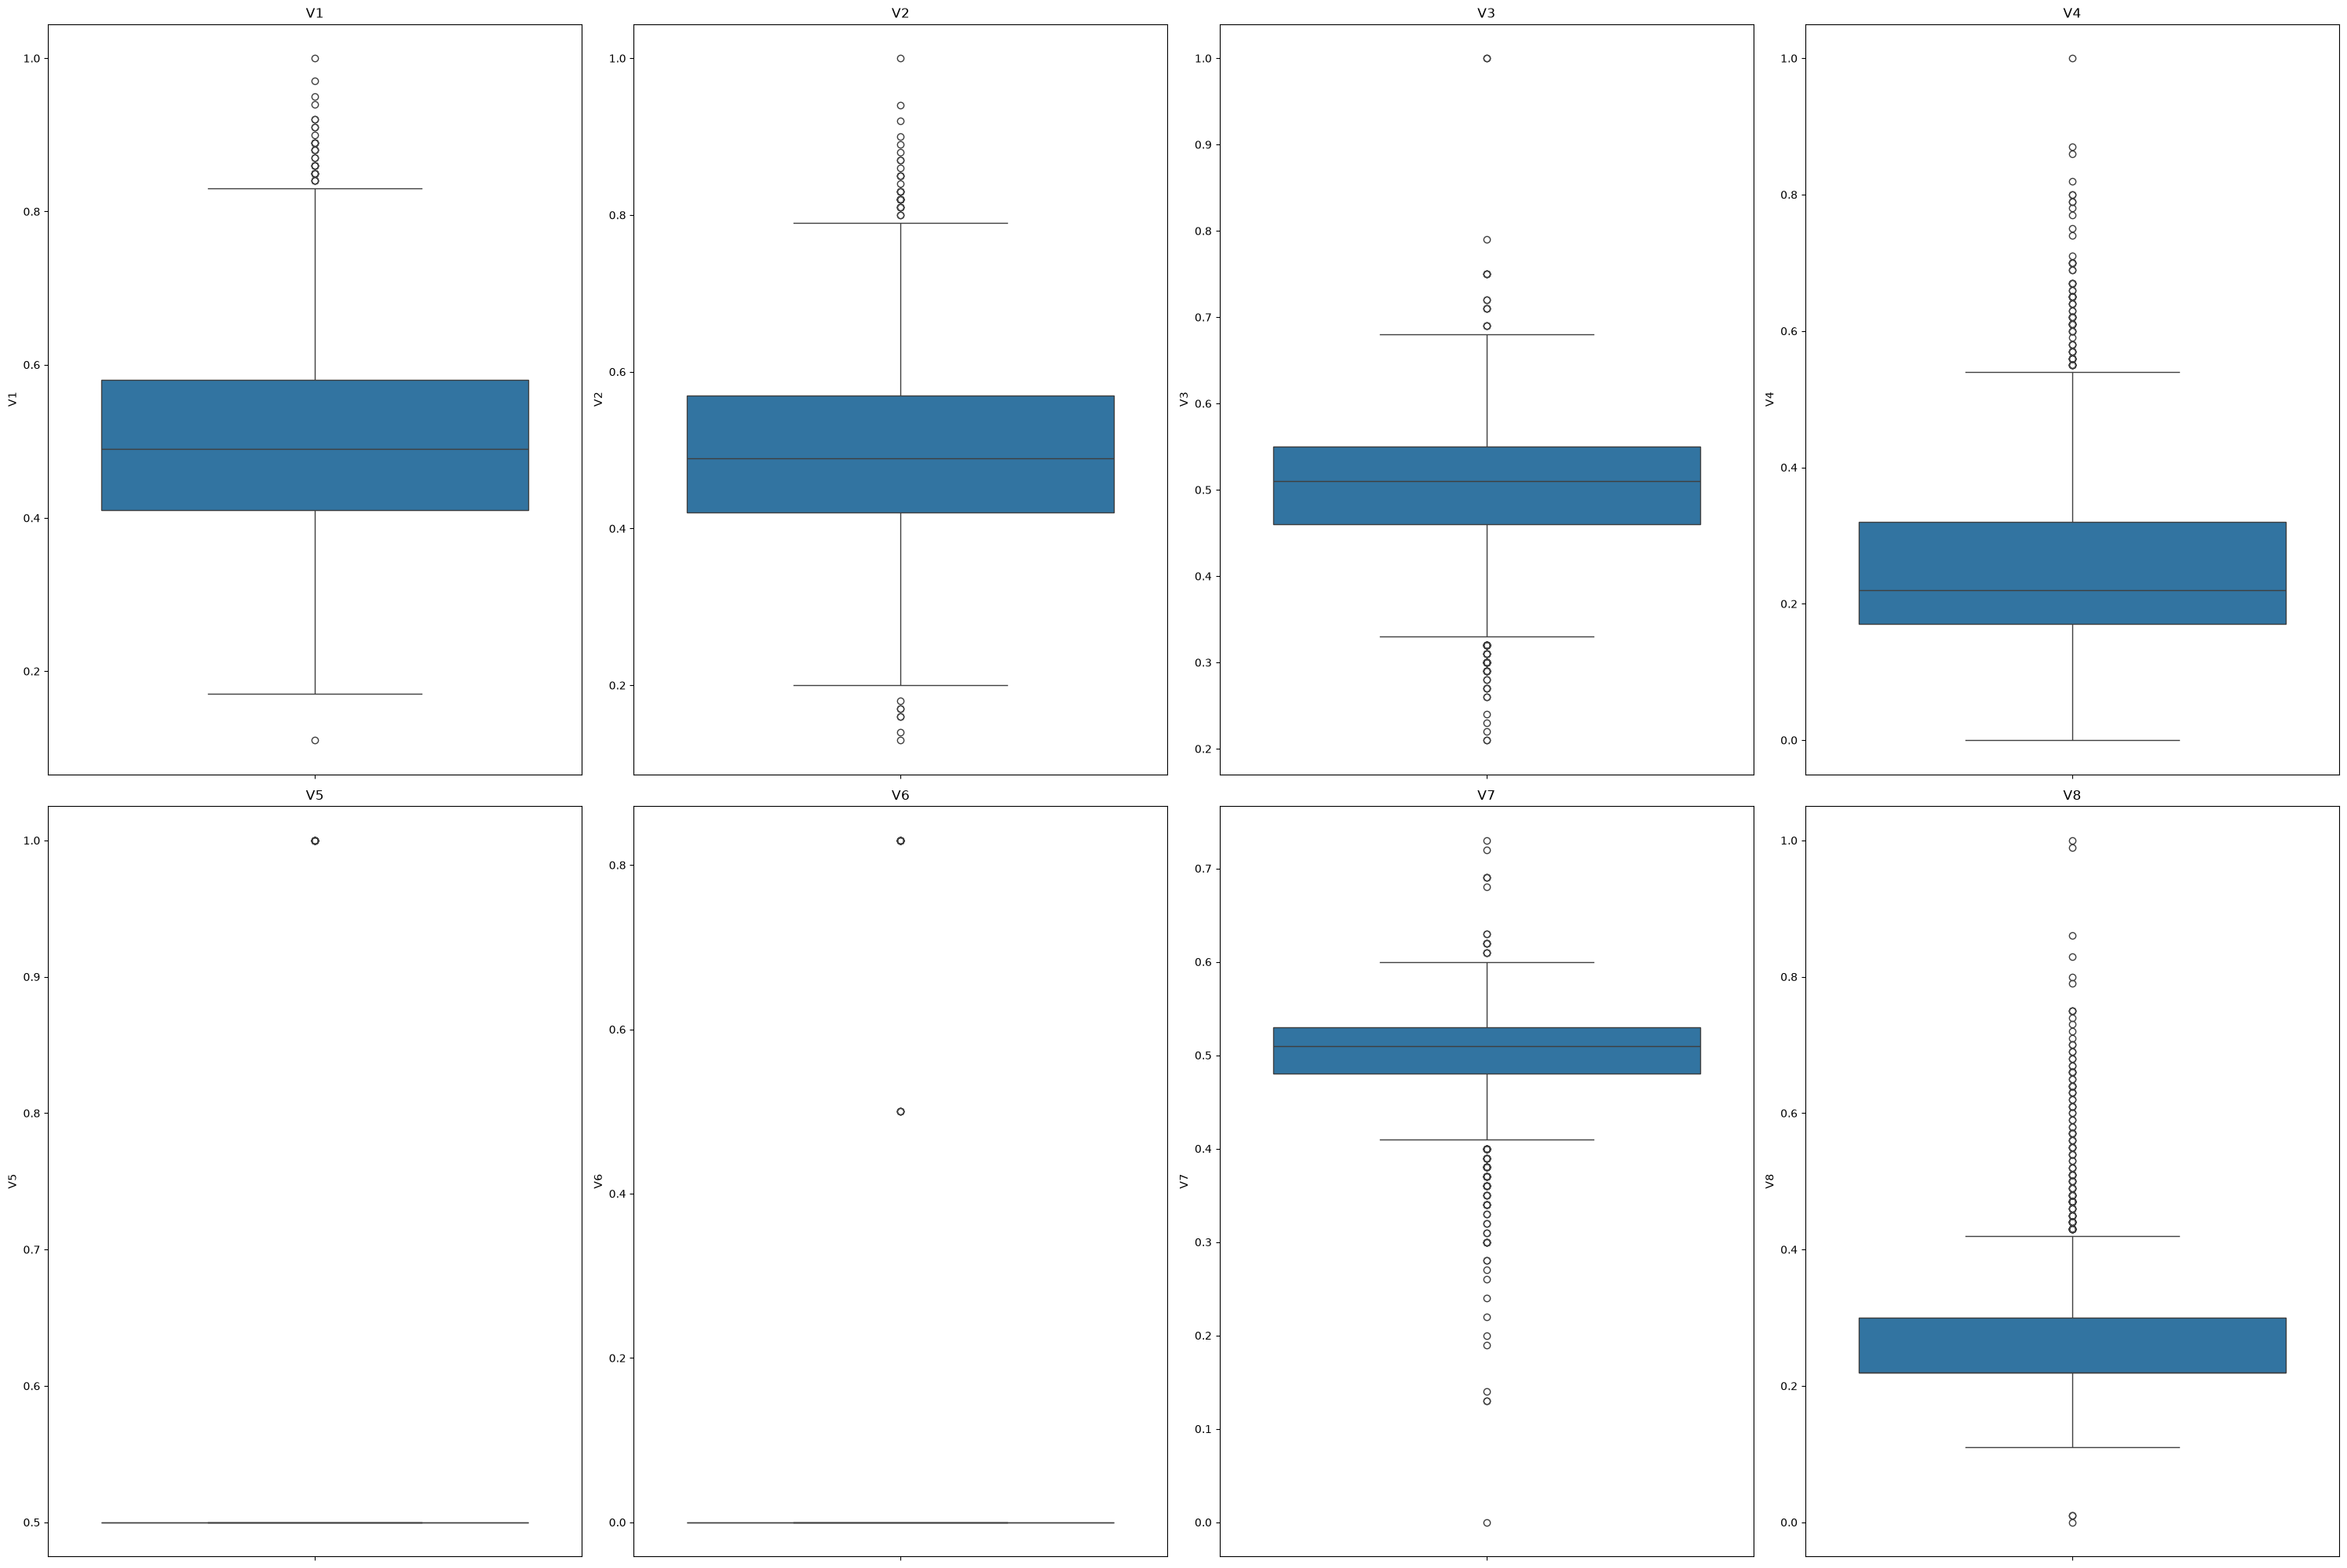

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30,30))
for pos, col in enumerate(df.columns[1:], start=1):
    plt.subplot(3,4, pos)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()

In [45]:
df['V8'].describe()

count    1484.000000
mean        0.276199
std         0.106491
min         0.000000
25%         0.220000
50%         0.220000
75%         0.300000
max         1.000000
Name: V8, dtype: float64

In [7]:
df.skew(numeric_only=True)

V1     0.604291
V2     0.416639
V3    -0.220995
V4     1.444776
V5    10.159633
V6    10.276884
V7    -1.791641
V8     2.413031
dtype: float64

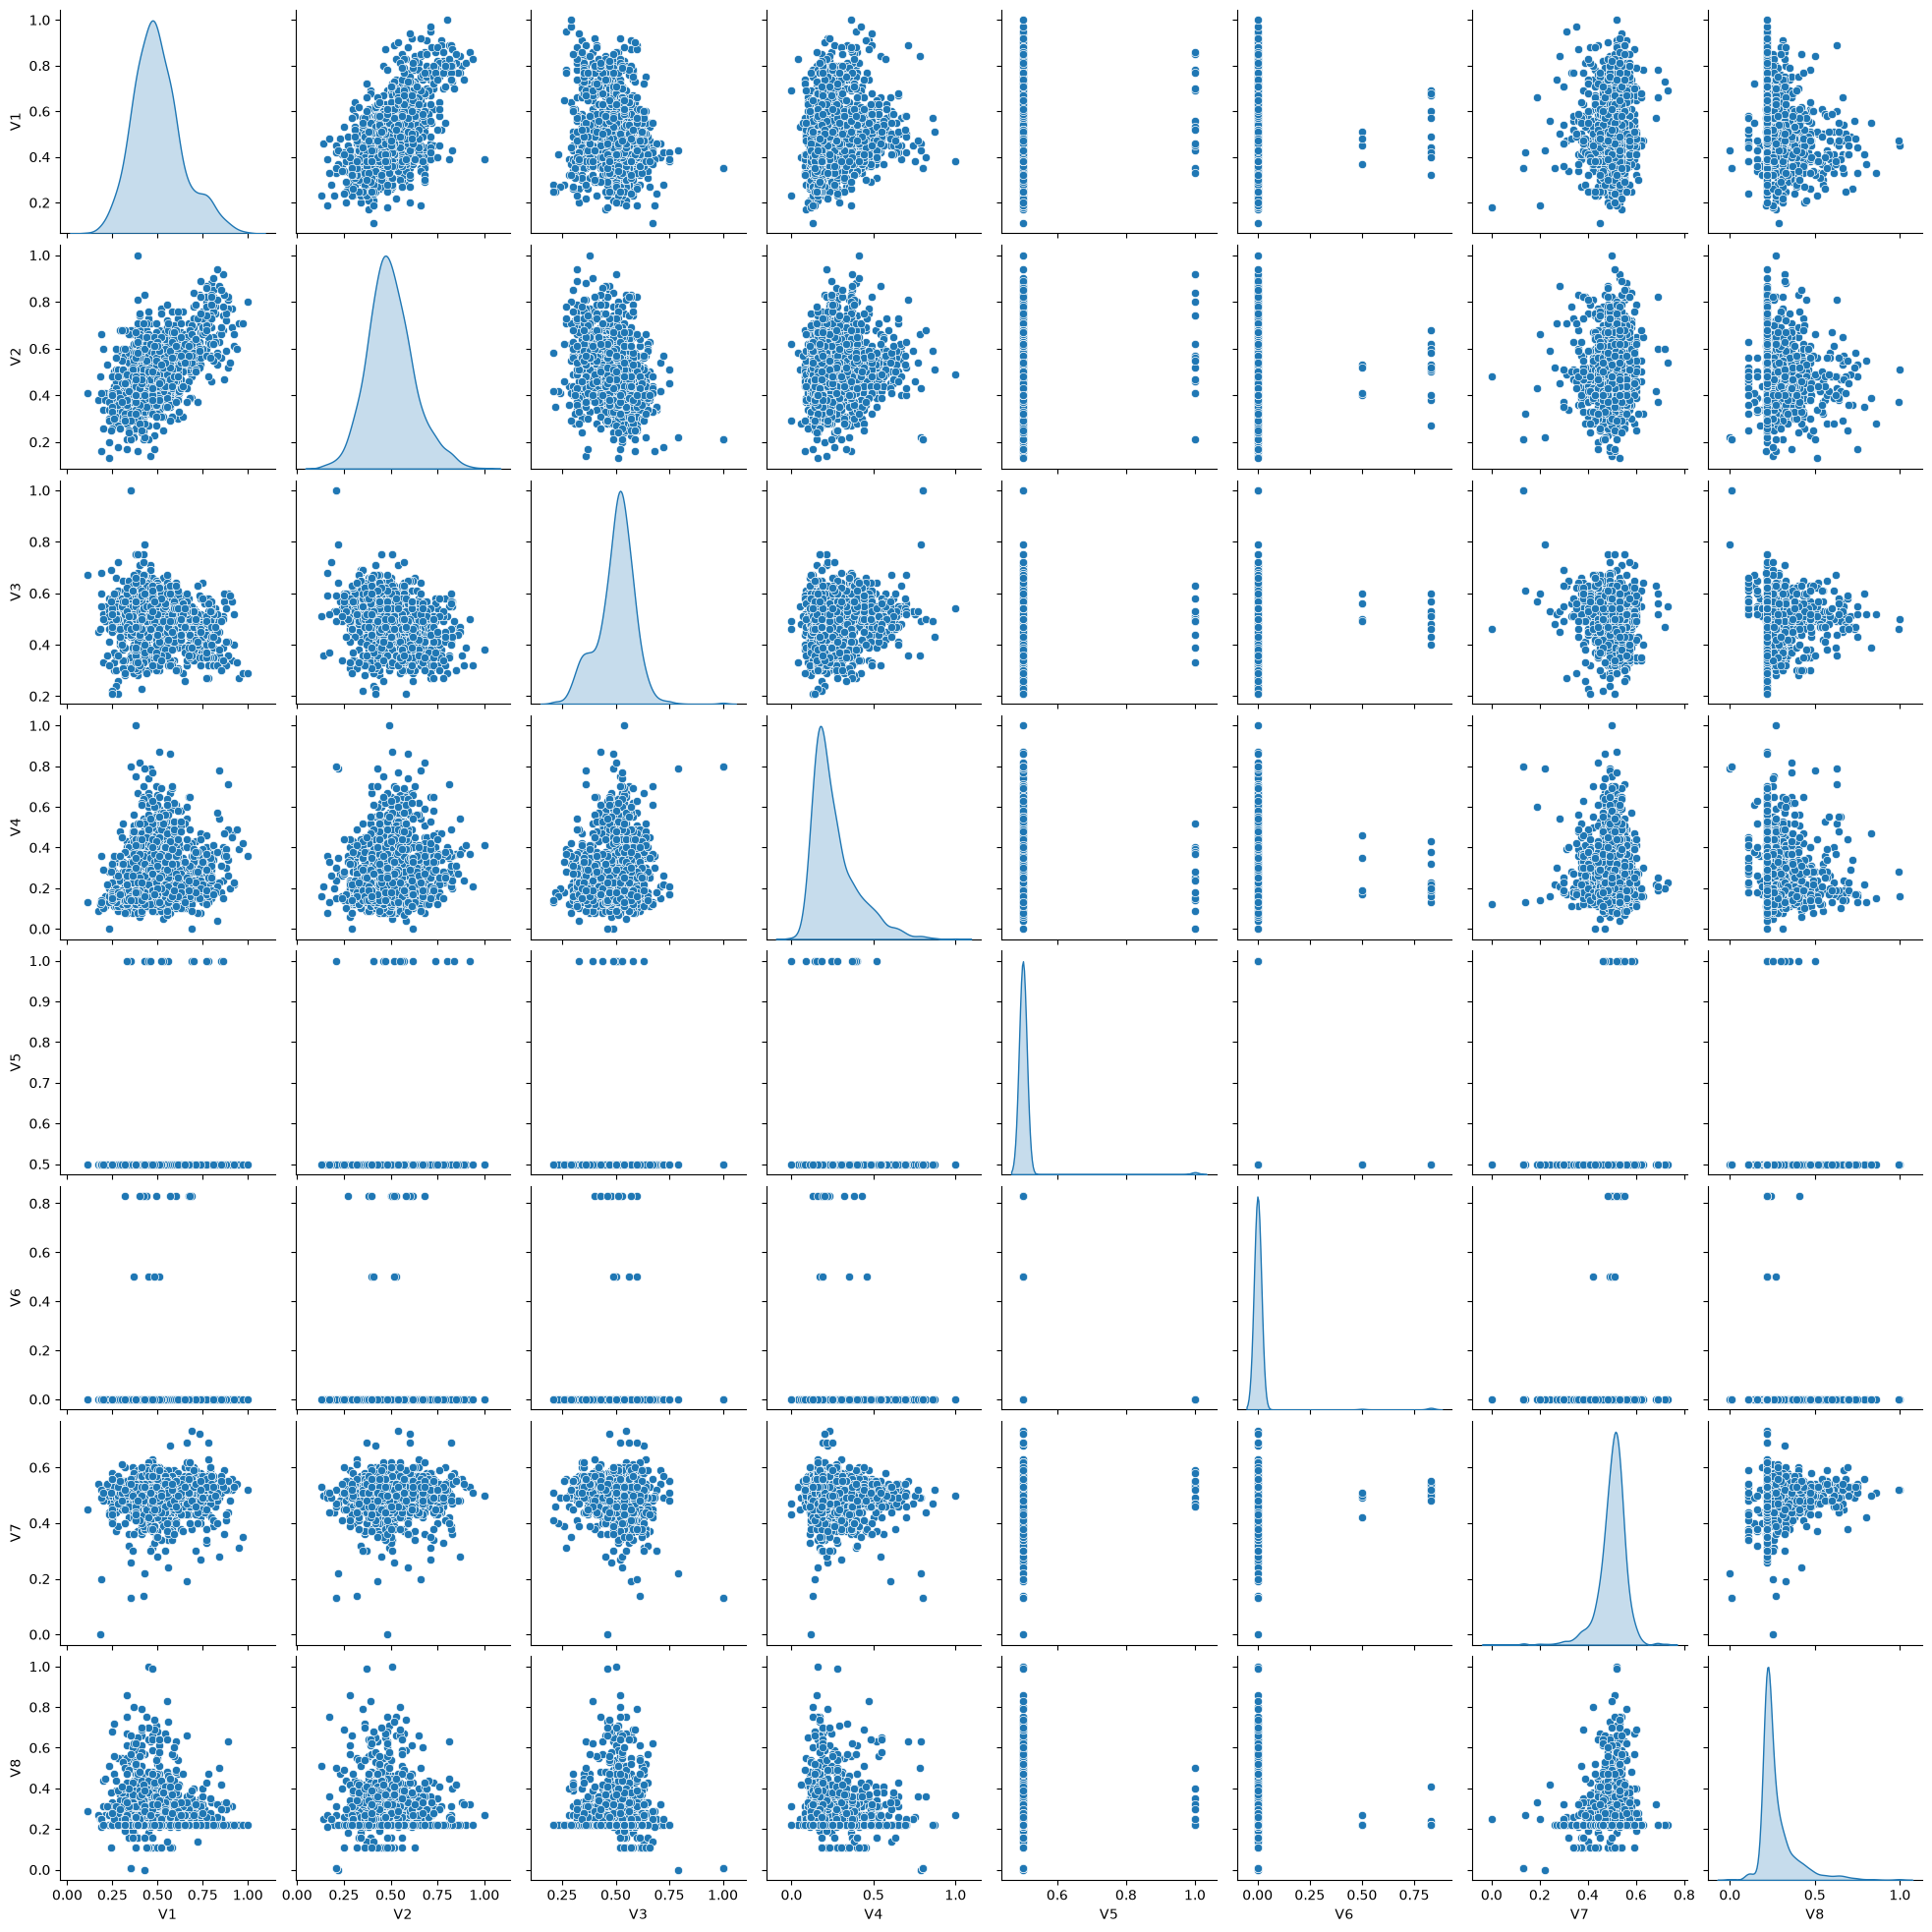

In [44]:
sns.pairplot(df, diag_kind='kde')

## 2. Comment the exploration of step 1 pointing out if there are imbalanced distributions, outliers, missing values, non–numeric fields with number of distinct values similar to the number of records 

V1: Symmetric (median ~0.49 centred in box). Outliers on both fences, more on the upper.

V2: Symmetric (median ~0.49). Outliers on both fences, more on the upper.

V3: Symmetric (median ~0.51, box 0.46–0.55). Outliers on both fences, more on the lower.

V4: Right-skewed. Long upper tail, outliers concentrated on the upper fence.

V5: Near-constant: 1470/1484 records equal 0.5. 14 records differ.

V6: Near-constant: 1469/1484 records equal 0.0. 15 records differ.

V7: Left-skewed with a very narrow IQR (0.48–0.53). Long lower tail.

V8: Right-skewed. 769/1484 records equal 0.22, so median = Q1.

All eight features lie on a 0–1 range, indicating the data is already normalised.

Outliers matter here because KMeans assigns points to the nearest centroid, and a
centroid is a mean — so extreme values pull centroids away from the dense region
and distort cluster boundaries. The objective is to minimise intra-cluster
variance while keeping clusters far apart; outliers work against both.

## 3. Drop the columns that are not relevant for the clustering operation, if any, and explain why you do that. Deal with missing values, if any 

In [2]:
# 3. V0 is an identifier: 1484 distinct values for 1484 records, so it carries no 
# information about similarity between records and cannot contribute to clustering.
df1 = df.drop(columns=['V0', 'V5', 'V6'])

## 4. find the best clustering scheme with KMeans, require not less than 3 clusters, show the hyperparameters, show the silhouette plots of clusters, show the distribution of the resulting cluster labels (e.g. histogram or pie plot) . 

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
grid = {'n_clusters': list(range(3,9)),
        'init' : ['k-means++', 'random']}
results = []
for param in ParameterGrid(grid):
    km = KMeans(**param, n_init= 10, random_state=42)
    labels = km.fit_predict(df1)
    results.append({**param,
                    'inertia': km.inertia_,
                    'silhouette': silhouette_score(df1, labels)})

results = pd.DataFrame(results).sort_values('silhouette', ascending=False)   
print(results)

         init  n_clusters    inertia  silhouette
6      random           3  68.694901    0.277711
0   k-means++           3  68.694697    0.277572
7      random           4  59.350545    0.277258
1   k-means++           4  59.350545    0.277258
2   k-means++           5  52.214452    0.215901
8      random           5  52.214588    0.215764
3   k-means++           6  48.469499    0.208046
9      random           6  48.470373    0.207804
4   k-means++           7  46.006485    0.183646
10     random           7  46.038459    0.179476
11     random           8  43.811613    0.170190
5   k-means++           8  43.758037    0.169978


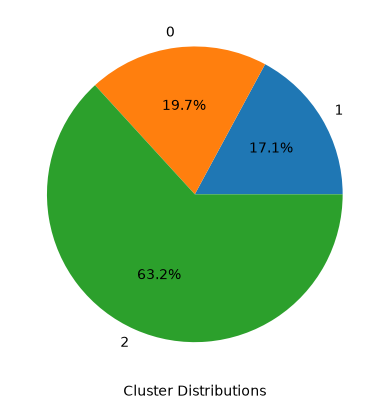

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

km = KMeans(init='random', n_clusters=3, n_init=10, random_state=42)
km_lables_best = km.fit_predict(df1)
pd.Series(km_lables_best).value_counts().sort_values().plot(kind='pie', autopct='%1.1f%%')
plt.xlabel('Cluster Distributions')
plt.show()

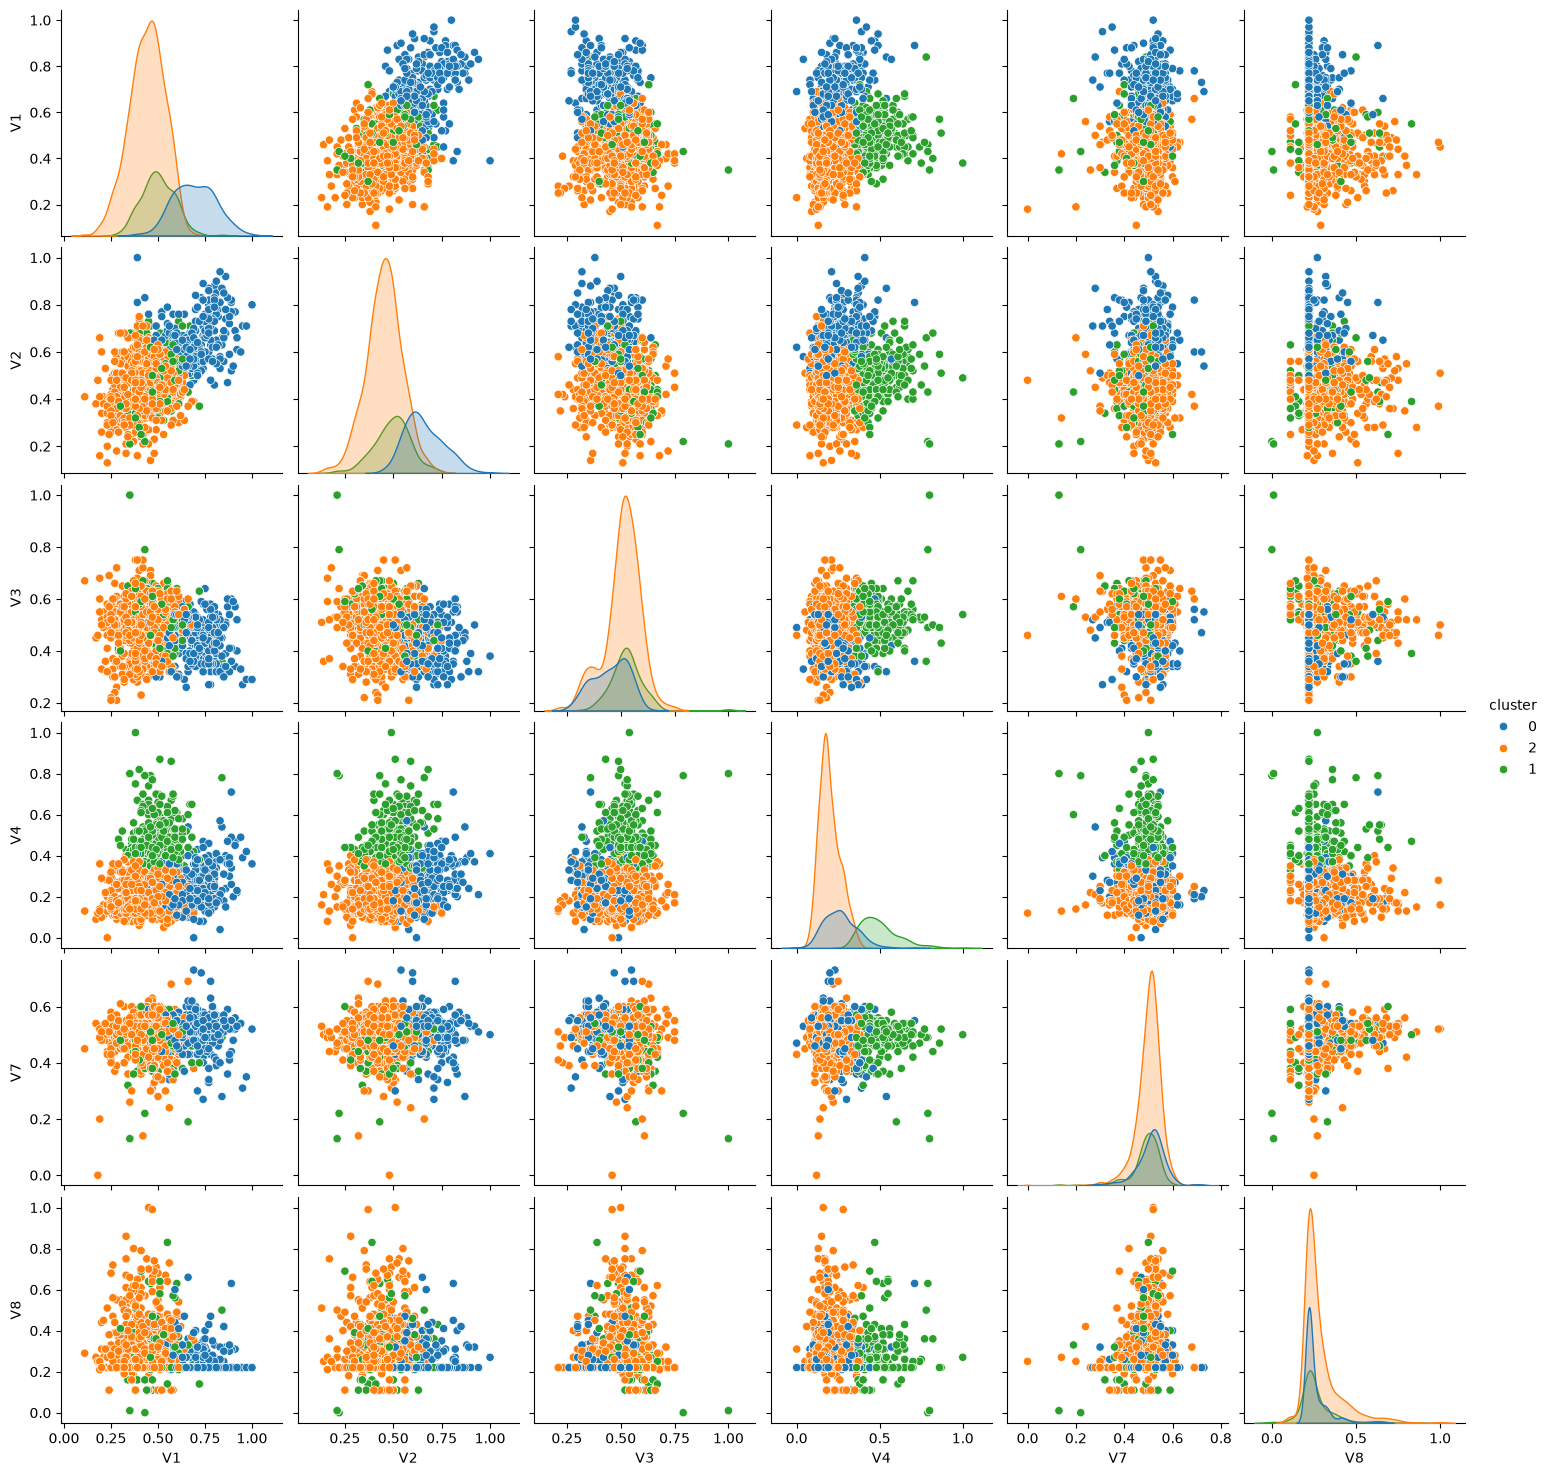

In [16]:
import seaborn as sns

df_plot = df1.copy()
df_plot['cluster'] = km_lables_best.astype('str')
sns.pairplot(df_plot, hue='cluster', diag_kind='kde')

## 5. find the best clustering scheme with Agglomerative Clustering or DB-SCAN (your choice), require not less than 3 clusters, show the hyper-parameters, show the silhouette plots of clusters, show the distribution of the resulting cluster labels (e.g. histogram or pie plot) .

In [21]:
from sklearn.model_selection import ParameterGrid 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

grid_agg = {'n_clusters':list(range(3,9)),
        'linkage':['ward','complete','average','single']}
results_agg = []
for params in ParameterGrid(grid_agg):
    agg = AgglomerativeClustering(**params)
    labels = agg.fit_predict(df1)
    results_agg.append({**params, 
                    'silhouette': silhouette_score(df1, labels)})

results_agg = pd.DataFrame(results_agg).sort_values('silhouette',ascending=False)
print(results_agg)

     linkage  n_clusters  silhouette
12   average           3    0.474631
18    single           3    0.457347
19    single           4    0.415817
13   average           4    0.380150
14   average           5    0.361060
20    single           5    0.359093
15   average           6    0.328336
21    single           6    0.296177
22    single           7    0.280140
6   complete           3    0.274207
23    single           8    0.272832
7   complete           4    0.270358
8   complete           5    0.266460
9   complete           6    0.261423
0       ward           3    0.259173
1       ward           4    0.255137
16   average           7    0.230405
2       ward           5    0.171492
10  complete           7    0.170070
17   average           8    0.161679
3       ward           6    0.158203
11  complete           8    0.139688
4       ward           7    0.133518
5       ward           8    0.123400


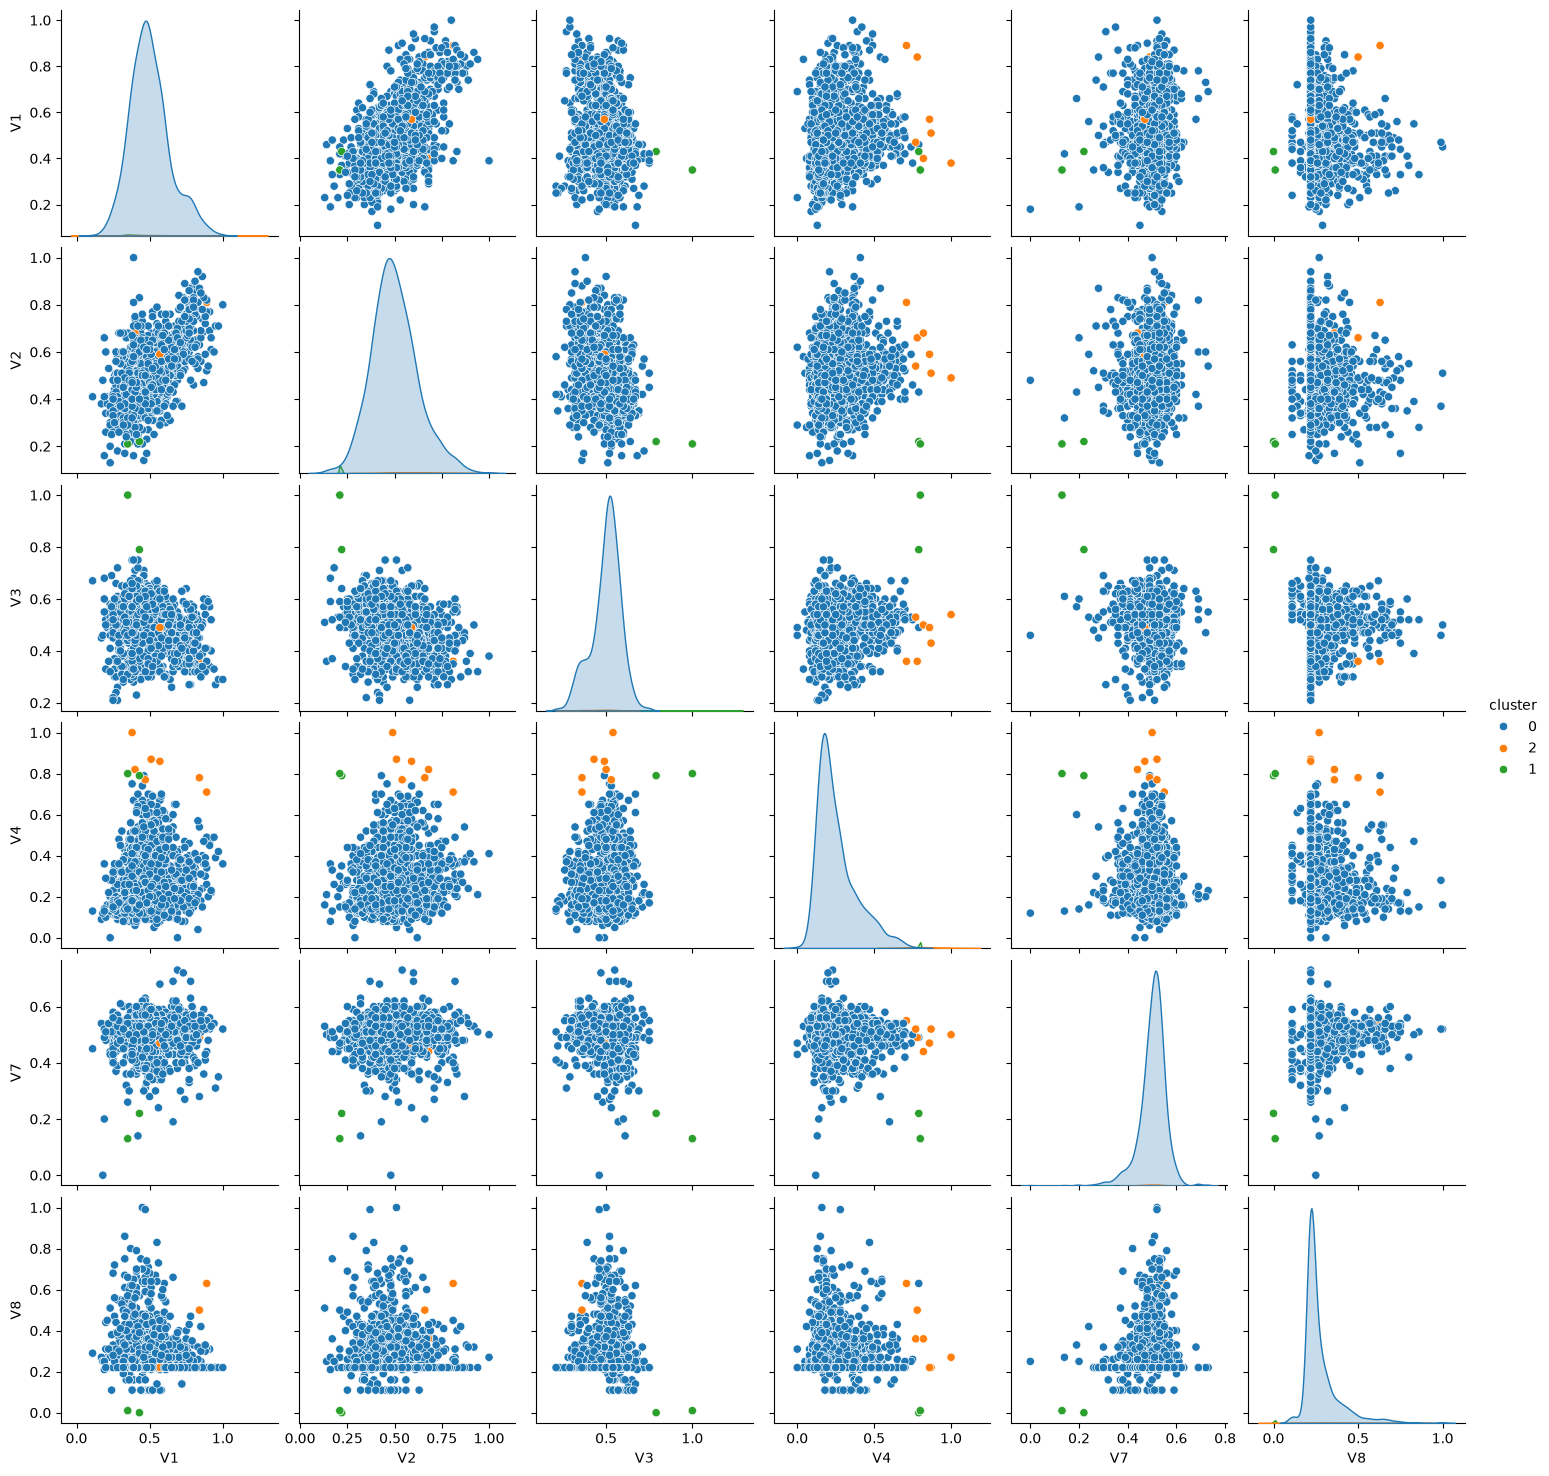

In [22]:
import seaborn as sns
agg_best = AgglomerativeClustering(n_clusters=3, linkage='average')
agg_best_label = agg_best.fit_predict(df1)
df1_plot = df1.copy()
df1_plot['cluster'] = agg_best_label.astype(str)
sns.pairplot(df1_plot, hue='cluster')

<Axes: >

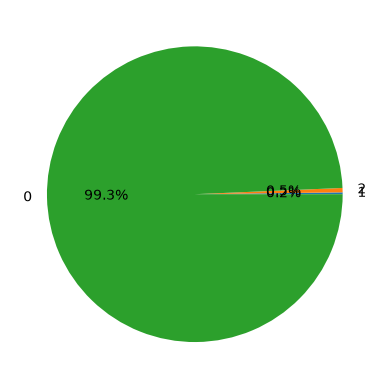

In [23]:

pd.Series(agg_best_label).value_counts().sort_values().plot(kind='pie',autopct='%1.1f%%')


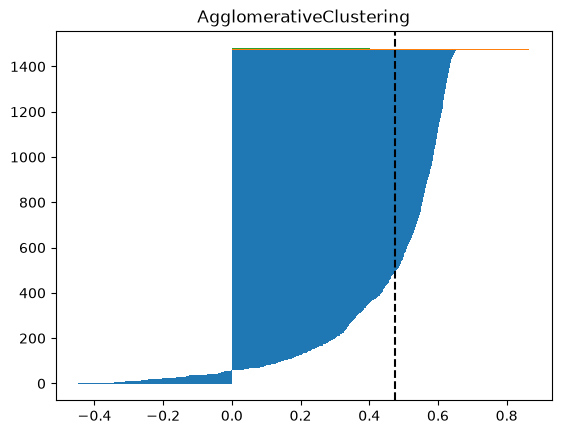

In [25]:
import numpy as np
from sklearn.metrics import silhouette_samples

def silhouette_plot(X, labels, title):
    y = 0
    sil = silhouette_samples(X, labels)
    for c in np.unique(labels):
        v = np.sort(sil[labels==c])
        plt.barh(range(y, y + len(v)), v, height=1.0)
        y += len(v)
    plt.axvline(sil.mean(), color='black', linestyle='--')
    plt.title(title)

silhouette_plot(df1, agg_best_label,title='AgglomerativeClustering')

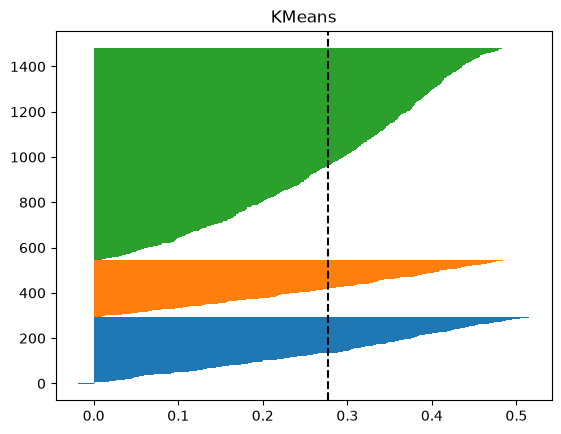

In [26]:
silhouette_plot(df1, km_lables_best, title='KMeans')

##  6. Comment the results . . . 


## 